# Multi-Fidelity Neural Networks

This section provides implementation for concepts related to multi-fidelity neural network models. Make sure that you have downloaded and installed the latest release of the `scimlstudio` package before running the code in this section. Go through [neural network section](nn_models.ipynb) before you proceed further. In this section, we will be focusing on multi-fidelity neural network (MFNN) framework proposed by [Meng and Karniadakis](https://doi.org/10.1016/j.jcp.2019.109020). This work proposes to learn the correlation between fidelities using a general function $F$. Mathematically, the correlation is written as

$$
    y_H = \mathcal{F}(\mathbf{x},y_L(\mathbf{x})),
$$

where $y_H$ and $y_L$ represents high and low fidelity data, and $\mathbf{x}$ denotes design variable vector. The function $\mathcal{F}$ is further decomposed into two parts: linear and nonlinear correlation, and is written as

$$
    \mathcal{F} = \mathcal{F}_L + \mathcal{F}_{NL}.
$$

The $\mathcal{F}_L$ and $\mathcal{F}_{NL}$ denote linear and nonlinear correlation function, respectively. Both these functions are approximated using a neural network model. Additionally, the relation $\mathbf{x}$ and $y_L$ is also modeled using a neural network. These networks are arranged as shown in below schematic.

```{image} images/mf_net.png
:width: 450px
:align: center
```

As mentioned earlier, there are three sub-networks here:

- $\mathcal{NN}_L$: learns mapping between $\mathbf{x}$ and $y_L$
- $\mathcal{NN}_{H_1}$: learns linear correlation between $y_L$ and $y_H$
- $\mathcal{NN}_{H_2}$: learns nonlinear correlation between $y_L$ and $y_H$

These three networks are trained together using a composite loss function, which is written as

$$
\mathcal{L}(\Theta_L, \Theta_{H_1}, \Theta_{H_2}) = MSE_L + MSE_H + \lambda_L \lVert \Theta_L \rVert^2 + \lambda_{H_1} \lVert \Theta_{H_1} \rVert^2 + \lambda_{H_2} \lVert \Theta_{H_2} \rVert^2
$$

The first and second term represents mean squared error (MSE) for the low- and high-fidelity data. The $\Theta_L$, $\Theta_{H_1}$, and $\Theta_{H_2}$ represents trainable parameters for $\mathcal{NN}_L$, $\mathcal{NN}_{H_1}$, and $\mathcal{NN}_{H_2}$, repsectively. The remaining terms are performing $L_2$ regularization for the trainable parameters. The $\lambda_L$, $\lambda_{H_1}$, and $\lambda_{H_2}$ represent regularization constant for each network.

The $MSE_L$ is written as

$$
    MSE_L = \frac{1}{N_{y_L}} \sum_{i=1}^{N_{y_L}} \Big[ y_L^{(i)} - \hat{y}_L(\mathbf{x}_L^{(i)}; \Theta_L) \Big]^2,
$$

where $\hat{y}_L$ represents $\mathcal{NN}_L$ and $N_{y_L}$ is the number of low-fidelity training points. The $MSE_H$ is written as

$$
    MSE_H = \frac{1}{N_{y_H}} \sum_{i=1}^{N_{y_H}} \Big[ y_H^{(i)} - \hat{y}_{H}(\mathbf{x}_H^{(i)}, \hat{y}_L(\mathbf{x}_H^{(i)}; \Theta_L); \Theta_{H_1}, \Theta_{H_2}) \Big]^2,
$$

where $N_{y_H}$ is the number of high-fidelity training points and $\hat{y}_{H}$ is the high-fidelity output. As mentioned earlier, $\hat{y}_{H}$ is the sum of linear and nonlinear correlation, and is written as

$$
    \hat{y}_H(\mathbf{x}_H^{(i)}, \hat{y}_L(\mathbf{x}_H^{(i)}; \Theta_L); \Theta_{H_1}, \Theta_{H_2}) = 
    \hat{y}_{H_1}(\mathbf{x}_H^{(i)}, \hat{y}_L(\mathbf{x}_H^{(i)}; \Theta_L); \Theta_{H_1}) + 
    \hat{y}_{H_2}(\mathbf{x}_H^{(i)}, \hat{y}_L(\mathbf{x}_H^{(i)}; \Theta_L); \Theta_{H_2}),
$$

where $\hat{y}_{H_1}$ and $\hat{y}_{H_2}$ denotes $\mathcal{NN}_{H_1}$ and $\mathcal{NN}_{H_2}$, respectively.

> __NOTE__: The design variables can be different for low and high-fidelity data. In this demonstration, it is assumed to be same, i.e., $\mathbf{x}_L = \mathbf{x}_H = \mathbf{x}$.

The loss function $\mathcal{L}$ can be minimized to obtain network parameters using standard optimizers like ADAM.

## Toy problem

To demonstrate MFNN, we will be using following function:

$$
\begin{gathered}
    y_L(x) =
    \begin{cases}
    0.5(6x - 2)^2 \sin(12x - 4) + 10(x - 0.5) - 5, & 0 \le x \le 0.5 \\[6pt]
    3 + 0.5(6x - 2)^2 \sin(12x - 4) + 10(x - 0.5) - 5, & 0.5 < x \le 1
    \end{cases} \\
    \text{and} \\
    y_H(x) =
    \begin{cases}
    2y_L(x) - 20x + 20, & 0 \le x \le 0.5 \\[6pt]
    4 + 2y_L(x) - 20x + 20, & 0.5 < x \le 1
    \end{cases}
\end{gathered}
$$

The $y_L$ and $y_H$ denotes low and high-fidelity function, respectively. 

Following code block imports required functions:

In [27]:
import torch
import matplotlib.pyplot as plt
from scimlstudio.models import MultifidelityNeuralNetwork, FeedForwardNeuralNetwork
from scimlstudio.utils import Standardize, evaluate_scalar

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.float32
args = {
    "device": device,
    "dtype": dtype
}

Next block defines low and high fidelity functions:

In [3]:
def low_fidelity(x):
    mask = x <= 0.5
    y = 0.5*(6*x - 2)**2 * torch.sin(12*x - 4) + 10*(x - 0.5) - 5
    y[~mask] = 3 + y[~mask]
    return y

def high_fidelity(x):
    mask = x <= 0.5
    y = 2*low_fidelity(x) - 20*x + 20
    y[~mask] = 4 + y[~mask]
    return y

## Training and testing data

Next block defines training and testing data. Note that here we are also using testing data for plotting the function.

In [4]:
# low fidelity training data
x_train_lf = torch.cat((torch.linspace(0, 0.35, 8), torch.linspace(0.4, 0.6, 22), torch.linspace(0.65, 1.0, 8)), axis=0).to(**args).reshape(-1,1)
y_train_lf = low_fidelity(x_train_lf)

# high fidelity training data
x_train_hf = torch.tensor([0.2, 0.4, 0.6, 0.7, 0.9], **args).reshape(-1,1)
y_train_hf = high_fidelity(x_train_hf)

# testing data
x_test = torch.linspace(0, 1, 100, **args).reshape(-1,1)
y_test_lf = low_fidelity(x_test)
y_test_hf = high_fidelity(x_test)

Below code block plots the function, along with the training points:

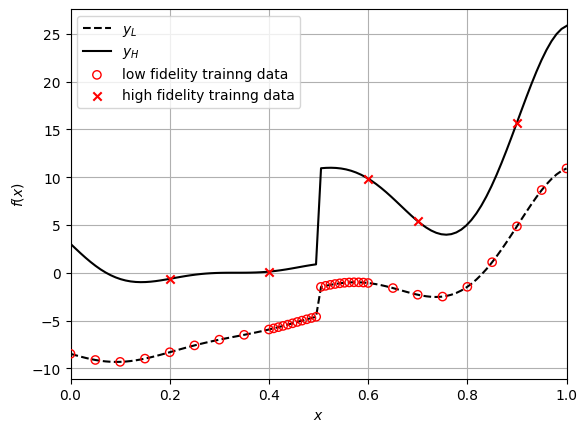

In [18]:
# true function
plt.plot(x_test.numpy(force=True), y_test_lf.numpy(force=True), "k--", label="$y_L$")
plt.plot(x_test.numpy(force=True), y_test_hf.numpy(force=True), "k-", label="$y_H$")

# training data
plt.scatter(x_train_lf.numpy(force=True), y_train_lf.numpy(force=True), marker="o", edgecolors="r", facecolors="None", label="low fidelity trainng data", zorder=10)
plt.scatter(x_train_hf.numpy(force=True), y_train_hf.numpy(force=True), c="r", marker="x", label="high fidelity trainng data", zorder=10)

# asthetics
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.xlim(left=0.0, right=1.0)
plt.grid()
_ = plt.legend()

Note the number of training points in each fidelity and how it is distributed. There are only five high-fidelity points, while there are 38 low-fidelity points. Moreover, the low-fidelity points are densely populated around the discountinuity, which will enable the model to learn this nonlinearity.

## Define MFNN model

We will use `MultiFidelityNeuralNetwork` class from `scimlstudio` package for creating MFNN. This class is similar to `FeedForwardNeuralNetwork` but with some modifications. You need to provide following arguments during initialization:

* `x_train_lf`: a 2D torch tensor representing input training data for low-fidelity
* `y_train_lf`: a 2D torch tensor representing output training data for low-fidelity
* `x_train_hf`: a 2D torch tensor representing input training data for high-fidelity
* `y_train_hf`: a 2D torch tensor representing output training data for high-fidelity
* `network_lf`: an instance of Sequential class defining the neural network model architecture for modeling low-fidelity data, i.e., $\mathcal{NN}_L$
* `network_linear_corr`: an instance of Sequential class defining the neural network model architecture for modeling linear correlation, i.e., $\mathcal{NN}_{H_1}$
* `network_nonlinear_corr`: an instance of Sequential class defining the neural network model architecture for modeling nonlinear correlation, i.e., $\mathcal{NN}_{H_2}$
* `input_transform`: an instance of Normalize or Standardize class used for input scaling, default = None
* `output_transform_lf`: an instance of Normalize or Standardize class used for output scaling of low-fidelity data, default = None
* `output_transform_hf`: an instance of Normalize or Standardize class used for output scaling of high-fidelity data, default = None

First, let’s define network architectures using the `Sequential` class. This is similar to [neural networks section](nn_models.ipynb), refer to that section for more details. Below code block defines these networks, initializes the weights, and creates input, output transformation objects.

In [22]:
# Weights initialization
def weights_init(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight.data)

# low-fidelity network
network_lf = torch.nn.Sequential(
    torch.nn.Linear(x_train_lf.shape[1], 128),
    torch.nn.Tanh(),
    torch.nn.Linear(128, 128),
    torch.nn.Tanh(),
    torch.nn.Linear(128, y_train_lf.shape[1])
).to(**args)

network_lf.apply(weights_init)

# linear correlation network
network_linear_corr = torch.nn.Sequential(
    torch.nn.Linear(x_train_hf.shape[1] + y_train_lf.shape[1], 64),
    torch.nn.Linear(64, 64),
    torch.nn.Linear(64, y_train_hf.shape[1])
).to(**args)

network_linear_corr.apply(weights_init)

# nonlinear correlation network
network_nonlinear_corr = torch.nn.Sequential(
    torch.nn.Linear(x_train_hf.shape[1] + y_train_lf.shape[1], 64),
    torch.nn.Tanh(),
    torch.nn.Linear(64, 64),
    torch.nn.Tanh(),
    torch.nn.Linear(64, y_train_hf.shape[1])
).to(**args)

network_nonlinear_corr.apply(weights_init)

# transforms
input_transform = Standardize(torch.vstack((x_train_lf, x_train_hf)))
output_transform_lf = Standardize(y_train_lf)
output_transform_hf = Standardize(y_train_hf)

# initialize mf model
mf_model = MultifidelityNeuralNetwork(
    x_train_lf=x_train_lf,
    y_train_lf=y_train_lf,
    x_train_hf=x_train_hf,
    y_train_hf=y_train_hf,
    network_lf=network_lf,
    network_linear_corr=network_linear_corr,
    network_nonlinear_corr=network_nonlinear_corr,
    input_transform=input_transform,
    output_transform_lf=output_transform_lf,
    output_transform_hf=output_transform_hf
)

> __NOTE__: The $\mathcal{NN}_{H_1}$ should not contain any nonlinear activation function since it is modeling a linear relation.

## Train MFNN model

Now, we can train the networks using the `fit` method from the `MultiFidelityNeuralNetwork` class object created in previous code block. This method takes following arguments:

* `optimizer`: an object from torch.optim module to optimize the network parameters
* `epochs`: number of epochs to train the network, default = 100
* `reg_const_lf`: regularization constant for low fidelity network $\mathcal{NN}_L$, default = 1e-4
* `reg_const_linear`: regularization constant for linear correlation network $\mathcal{NN}_{H_1}$, default = 0.0
* `reg_const_nonlinear`: regularization constant for nonlinear correlation network $\mathcal{NN}_{H_2}$, default = 1e-3

Below code block defines these arguments and trains the model. Refer to [neural networks section](nn_models.ipynb) for more details about how to define `optimizer`. Note that the loss function is internally defined.

In [ ]:
optimizer = torch.optim.Adam(mf_model.parameters, lr=1e-3)

mf_model.fit(
    optimizer=optimizer,
    epochs=1000,
    reg_const_lf=1e-4,
    reg_const_linear=0.0,
    reg_const_nonlinear=1e-3
)

## Predict

Once networks are trained, we can do predictions using it. You can use `predict` method from the `MultiFidelityNeuralNetwork` class object for doing predictions. Note that the values returned by the `predict` method are high-fidelity predictions. Below code evaluates network on the testing data:

In [29]:
y_test_mf_pred = mf_model.predict(x_test.reshape(-1,1))

## DNN through HF data

For comparison, we are also creating a fully-connected neural network model through the high-fidelity data. This will allow us to see the advantage of using multi-fidelity models.

In [28]:
network_hf = torch.nn.Sequential(
    torch.nn.Linear(x_train_hf.shape[1], 64),
    torch.nn.Tanh(),
    torch.nn.Linear(64, 64),
    torch.nn.Tanh(),
    torch.nn.Linear(64, 64),
    torch.nn.Tanh(),
    torch.nn.Linear(64, 1),
).to(**args)

# initial weights
network_hf.apply(weights_init)

# initialize the model class
sf_model = FeedForwardNeuralNetwork(
    x_train_hf,
    y_train_hf,
    network_hf,
    Standardize(x_train_hf),
    Standardize(y_train_hf)
)

optimizer = torch.optim.Adam(sf_model.parameters, lr=0.01) # adam optimizer

loss_func = torch.nn.MSELoss() # mean squared error loss function

# since the training data is small, we are using entire data
batch_size = x_train_hf.shape[0] 

epochs = 500 # number of epochs

sf_model.fit(optimizer, loss_func, batch_size,epochs) # call the fit method

y_test_sf_pred = sf_model.predict(x_test.reshape(-1,1)) # predict

## Comparison plot

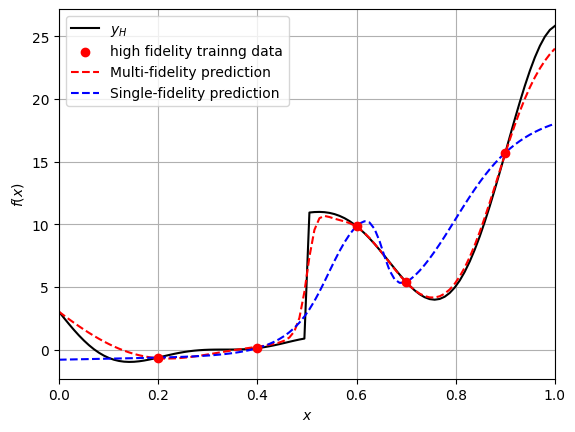

In [32]:
fig, ax = plt.subplots()

# true function
plt.plot(x_test.numpy(force=True), y_test_hf.numpy(force=True), "k-", label="$y_H$")

# HF training data
plt.scatter(x_train_hf.numpy(force=True), y_train_hf.numpy(force=True), c="r", marker="o", label="high fidelity trainng data", zorder=10)

# predictions
plt.plot(x_test.numpy(force=True), y_test_mf_pred.numpy(force=True), "r--", label="Multi-fidelity prediction")
plt.plot(x_test.numpy(force=True), y_test_sf_pred.numpy(force=True), "b--", label="Single-fidelity prediction")

# asthetics
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.xlim(left=0.0, right=1.0)
plt.grid()
_ = plt.legend()

Note that a single NN model through the high-fidelity data is not able to learn the underlying function since the number of points is less. However, the multi-fidelity model is able to approximate the true high-fidelity function with large number of low-fidelity points, along with small number of high-fidelity points.